In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

print(df.head())

print(df.shape)

print(df.info())

   match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
0   1741000          1                      48                       35   
1  30579330          0                      52                       40   
2  38763513          1                      42                       45   
3  39165037          1                      39                       26   
4  39162555          0                      37                       34   

   team0_team_total_networth  team0_team_total_damage  \
0                     166321                   127231   
1                     167923                   138069   
2                     182109                   133240   
3                     174473                   118950   
4                     155575                   125247   

   team0_team_total_objectivedamage  team0_team_avg_level  \
0                             25378             21.666667   
1                             11407             27.666667   
2                      

# Inspecting Missing Values and Data/Features Distributions

In [3]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [4]:
print(df["team0_won"].value_counts())

print(df["team0_won"].value_counts(normalize=True))

team0_won
1    7978
0    7901
Name: count, dtype: int64
team0_won
1    0.502425
0    0.497575
Name: proportion, dtype: float64


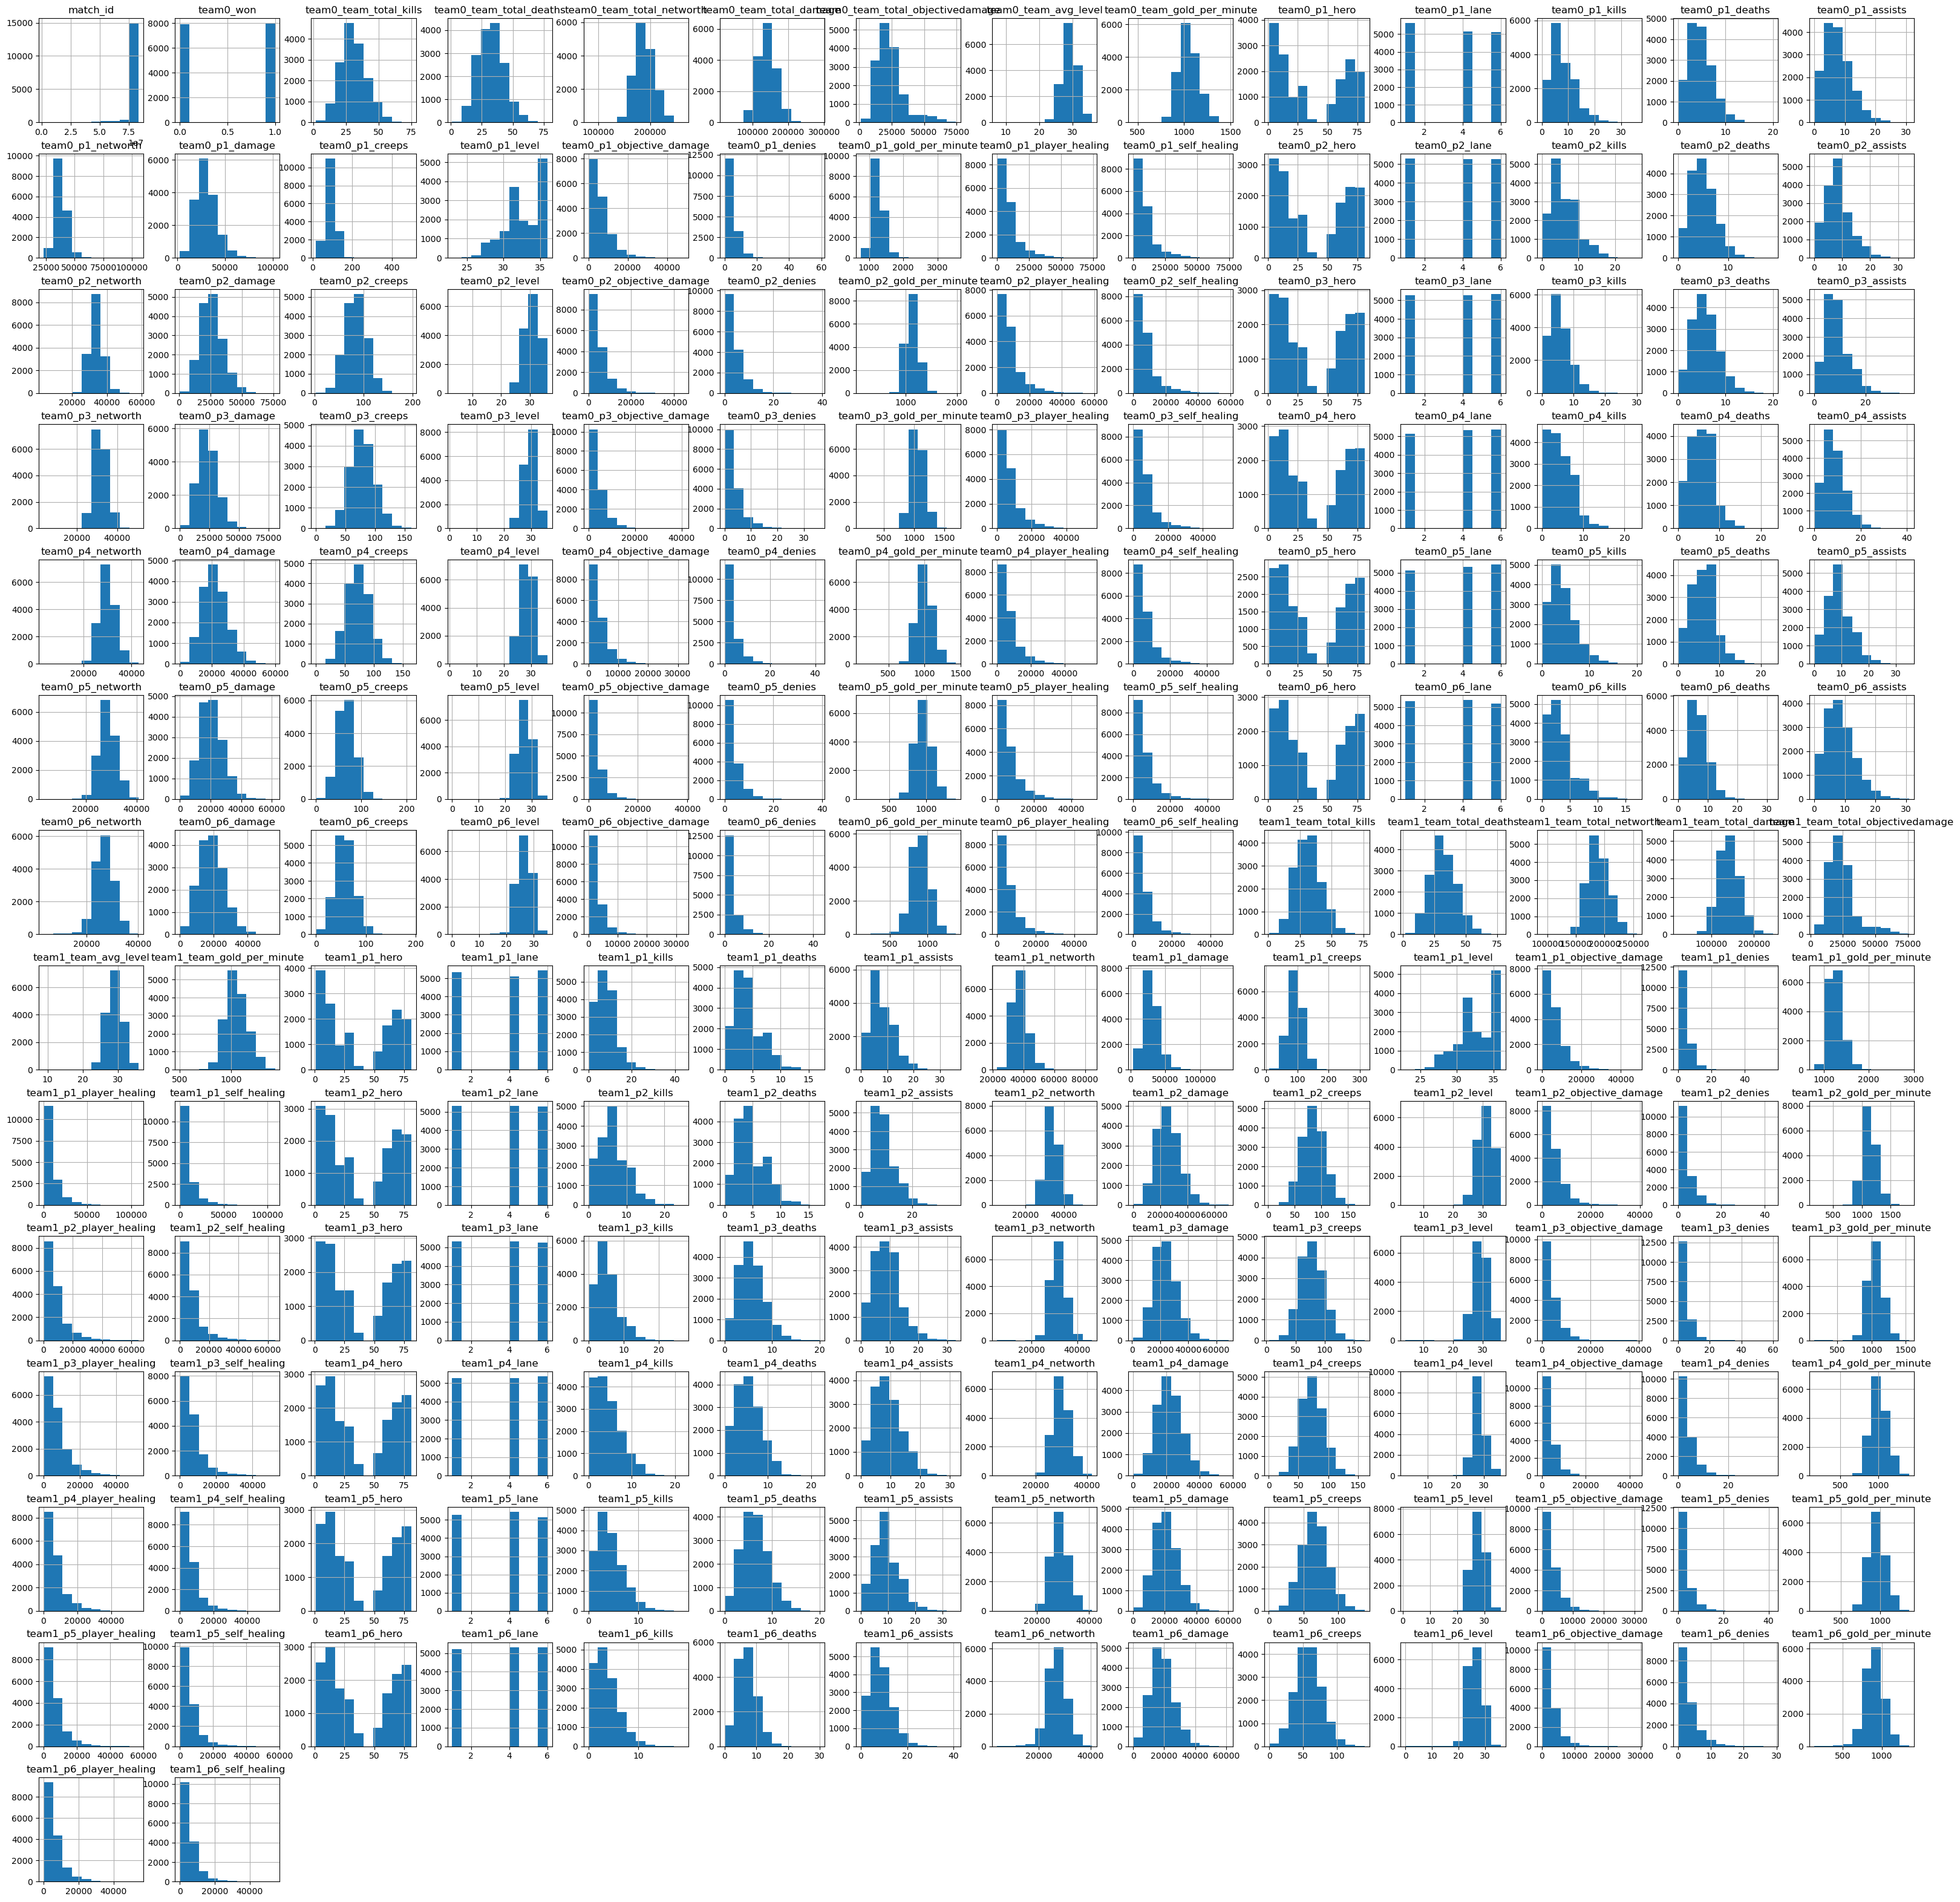

In [5]:
df.hist(figsize=(40, 40))

plt.show()

# Removing Outliers

count     15879.000000
mean     188718.403678
std       18915.769320
min       81045.000000
25%      175371.500000
50%      187213.000000
75%      200990.500000
max      264049.000000
Name: team0_team_total_networth, dtype: float64


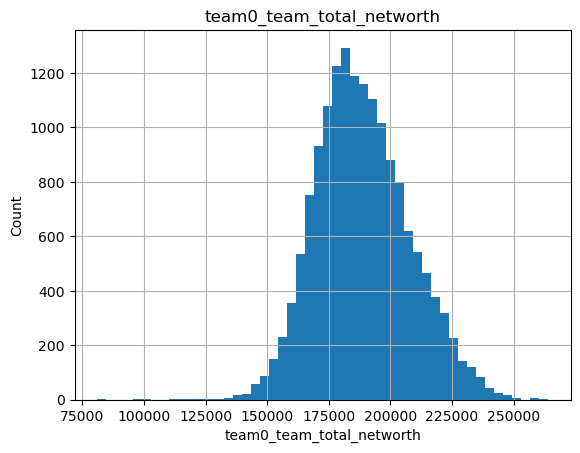

In [6]:
feature = "team0_team_total_networth"

print(df[feature].describe())

df[feature].hist(bins=50)

plt.title(feature)

plt.xlabel(feature)

plt.ylabel("Count")

plt.show()

In [7]:
threshold = 100000

count = (df["team0_team_total_networth"] < threshold).sum()

print(count)

outliers = df[df["team0_team_total_networth"] < 100000]

print((outliers.head(20)))

2
       match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
3823   82174414          0                       3                       16   
15148  83239773          0                       7                        6   

       team0_team_total_networth  team0_team_total_damage  \
3823                       96731                    22179   
15148                      81045                    24656   

       team0_team_total_objectivedamage  team0_team_avg_level  \
3823                              15970             14.666667   
15148                              5260              9.000000   

       team0_team_gold_per_minute  team0_p1_hero  ...  team1_p6_assists  \
3823                   537.394427             10  ...                 4   
15148                  450.249985              1  ...                 0   

       team1_p6_networth  team1_p6_damage  team1_p6_creeps  team1_p6_level  \
3823                7029             2593                8               6  

# Inspecting Correlations

In [8]:
corr = df.corr(numeric_only=True)

print(corr["team0_won"].sort_values(ascending=False))

team0_won                     1.000000
team0_team_total_networth     0.516031
team0_team_gold_per_minute    0.515046
team0_p4_networth             0.461580
team0_p4_gold_per_minute      0.461023
                                ...   
team1_p3_networth            -0.455406
team1_p4_gold_per_minute     -0.457686
team1_p4_networth            -0.458078
team1_team_gold_per_minute   -0.515712
team1_team_total_networth    -0.516452
Name: team0_won, Length: 184, dtype: float64
